# Homework 3 

## Task 1

### 1)  Study the header of the dataset (in unclear cases you can also use the OLTP schema, which you can find in the zip file for the second lesson!). Describe the number of columns, the number of rows, and the data types of the columns. 

1.1 Inspecting the structure of the dataset  

In [76]:
import pandas as pd
import os

df_sneakers = pd.read_csv('sneaker_sales_dataset.csv')

# general structure,  number of columns, the number of rows, and the data types of the columns
print(df_sneakers.info())

# first five rows
print(df_sneakers.head(5))

# numeric columns summary
print(df_sneakers.describe())

# string columns summary
print(df_sneakers.describe(include=object))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       5000 non-null   int64  
 1   transaction_date     5000 non-null   object 
 2   customer_id          5000 non-null   int64  
 3   customer_name        5000 non-null   object 
 4   customer_birth_year  5000 non-null   int64  
 5   customer_discount    5000 non-null   int64  
 6   customer_country     5000 non-null   object 
 7   store_name           5000 non-null   object 
 8   store_city           5000 non-null   object 
 9   store_country        5000 non-null   object 
 10  sneaker_id           5000 non-null   int64  
 11  brand                5000 non-null   object 
 12  model                5000 non-null   object 
 13  category             5000 non-null   object 
 14  color                5000 non-null   object 
 15  size_eu              5000 non-null   i

1.2 Checking and adjusting Data Types

In [77]:
print(df_sneakers.dtypes)

transaction_id           int64
transaction_date        object
customer_id              int64
customer_name           object
customer_birth_year      int64
customer_discount        int64
customer_country        object
store_name              object
store_city              object
store_country           object
sneaker_id               int64
brand                   object
model                   object
category                object
color                   object
size_eu                  int64
price_per_pair         float64
num_pairs                int64
final_price            float64
dtype: object


The transaction_date column has type object, so it is converted to datetime.
Extract the month number from transaction_date (YYYY-MM-DD) (for easier further analysis)

In [78]:
df_sneakers['transaction_date'] = pd.to_datetime(df_sneakers['transaction_date'])
df_sneakers['month'] = df_sneakers['transaction_date'].dt.month

### 2) Check the quality of the data – if there are missing values, duplicate transactions, or anomalies in numerical data (for example, unexpected shoe sizes)  

2.1 Checking missing values, duplicated transaction IDs

In [79]:
print(df_sneakers.isna().sum())
# duplicated transaction IDs
print('duplicated transaction IDs', df_sneakers['transaction_id'].count() - df_sneakers['transaction_id'].nunique())
# duplicated transaction IDs transaction_id and sneaker_id
print('duplicated transaction IDs and sneaker_id', df_sneakers.duplicated(subset=['transaction_id', 'sneaker_id']).sum())

transaction_id         0
transaction_date       0
customer_id            0
customer_name          0
customer_birth_year    0
customer_discount      0
customer_country       0
store_name             0
store_city             0
store_country          0
sneaker_id             0
brand                  0
model                  0
category               0
color                  0
size_eu                0
price_per_pair         0
num_pairs              0
final_price            0
month                  0
dtype: int64
duplicated transaction IDs 0
duplicated transaction IDs and sneaker_id 0


In [80]:
s = pd.Series(df_sneakers['transaction_date'].unique())
s_date = pd.to_datetime(s).sort_values(ascending=True)

# min–max dates
print(s_date.min())
print(s_date.max())

# gaps in dates
print('gaps in dates',s_date.diff().value_counts())

2024-01-01 00:00:00
2024-12-30 00:00:00
gaps in dates 1 days    364
Name: count, dtype: int64


There are no missing data. The dates are continuous, and there are no missing days.

2.3 Checking anomalies in numerical data

In [81]:
numerical_cols = ['size_eu', 'price_per_pair', 'num_pairs', 'final_price', 'transaction_id', 'customer_id', 'customer_birth_year', 'customer_discount', 'sneaker_id']

print(df_sneakers[numerical_cols].describe())

           size_eu  price_per_pair    num_pairs  final_price  transaction_id  \
count  5000.000000     5000.000000  5000.000000  5000.000000     5000.000000   
mean     41.638400      101.847280     1.978400   191.300498     2500.500000   
std       3.502528       19.779977     0.812198    88.564217     1443.520003   
min      36.000000       63.950000     1.000000    57.560000        1.000000   
25%      39.000000       88.670000     1.000000   110.425000     1250.750000   
50%      42.000000       99.970000     2.000000   185.870000     2500.500000   
75%      45.000000      117.470000     3.000000   254.390000     3750.250000   
max      47.000000      151.040000     3.000000   453.120000     5000.000000   

       customer_id  customer_birth_year  customer_discount    sneaker_id  
count  5000.000000          5000.000000        5000.000000  5.000000e+03  
mean    993.511000          1987.484800           5.056000  4.056893e+06  
std     579.585365            10.356101           4.07

2.3.1 Inspecting coulumn size_eu

numeric stats size_eu 
 count    5000.000000
mean       41.638400
std         3.502528
min        36.000000
25%        39.000000
50%        42.000000
75%        45.000000
max        47.000000
Name: size_eu, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_18124\3363638293.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'size_eu':'size'}, inplace=True)


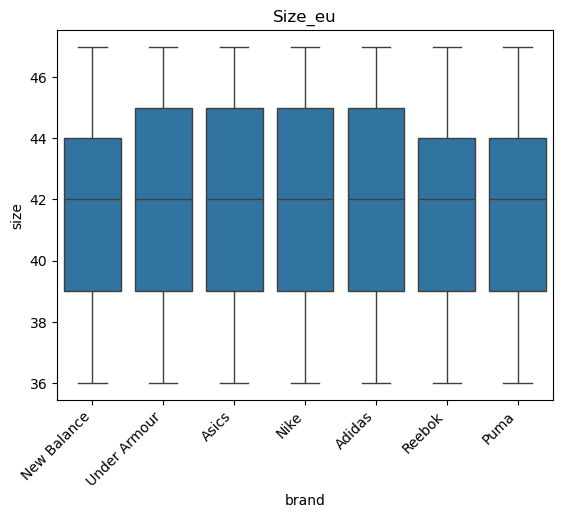

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('numeric stats size_eu \n',df_sneakers['size_eu'].describe())

df = df_sneakers[['brand','size_eu']]
df.rename(columns={'size_eu':'size'}, inplace=True)

sns.boxplot(data=df, x='brand', y='size').set_title('Size_eu')
plt.xticks(rotation=45, ha='right')
plt.show()

Conclusion: shoe sizes range from EU 36 to 47, with an average size of about 42, which is typical for adult shoes. There are no anomalies or outliers. The data is suitable for analysis.

2.3.2 Inspecting coulumn price_per_pair

numeric stats price_per_pair 
 count    5000.000000
mean      101.847280
std        19.779977
min        63.950000
25%        88.670000
50%        99.970000
75%       117.470000
max       151.040000
Name: price_per_pair, dtype: float64
brand
Adidas    83741.08
Nike      83603.35
Name: price_per_pair, dtype: float64
brand
Puma      59846.00
Reebok    63728.07
Name: price_per_pair, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_18124\3164325772.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'price_per_pair':'price'}, inplace=True)


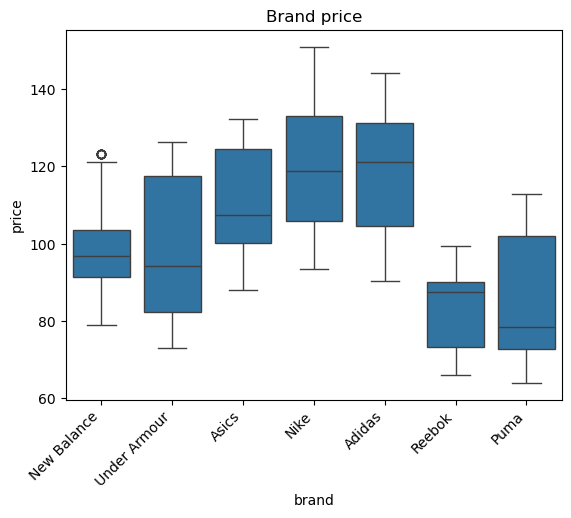

In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('numeric stats price_per_pair \n',df_sneakers['price_per_pair'].describe())
# Top-2 brands by price_per_pair
print(df_sneakers.groupby('brand')['price_per_pair'].sum().sort_values(ascending=False).head(2))
print(df_sneakers.groupby('brand')['price_per_pair'].sum().sort_values(ascending=True).head(2))

df = df_sneakers[['brand','price_per_pair']]
df.rename(columns={'price_per_pair':'price'}, inplace=True)

sns.boxplot(data=df, x='brand', y='price').set_title('Brand price')
plt.xticks(rotation=45, ha='right')
plt.show()

Conclusion: the price range is moderate, with no extremely cheap or expensive values. The two most expensive brands are Adidas and Nike, and the two cheapest brands are Reebok and Puma. There are no anomalies or outliers. The data is suitable for analysis.

2.3.3 Inspecting coulumn num_pairs

numeric stats num_pairs 
 count    5000.000000
mean        1.978400
std         0.812198
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         3.000000
Name: num_pairs, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_18124\2014862997.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'num_pairs':'Number of Pairs'}, inplace=True)


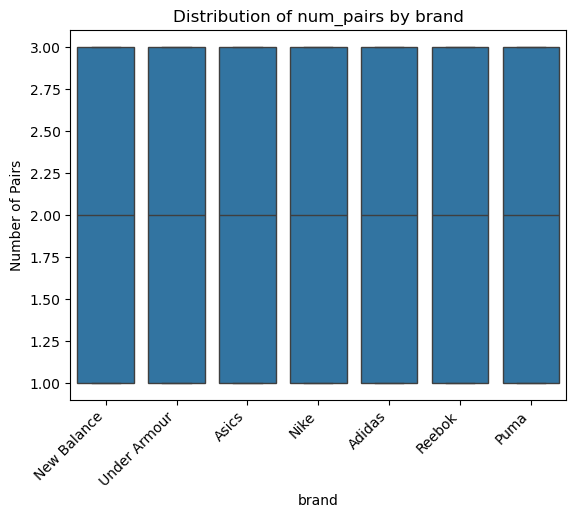

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('numeric stats num_pairs \n',df_sneakers['num_pairs'].describe())

df = df_sneakers[['brand','num_pairs']]
df.rename(columns={'num_pairs':'Number of Pairs'}, inplace=True)

sns.boxplot(data=df, x='brand', y='Number of Pairs').set_title('Distribution of num_pairs by brand')
plt.xticks(rotation=45, ha='right')
plt.show()

Conclusion: most purchases are 1–3 pairs at a time, which is typical for retail sales and does not depend on the brand. There are no anomalies or outliers. The data is suitable for analysis.

2.3.4 Inspecting coulumn final_price

numeric stats final_price 
 count    5000.000000
mean      191.300498
std        88.564217
min        57.560000
25%       110.425000
50%       185.870000
75%       254.390000
max       453.120000
Name: final_price, dtype: float64
brand
Nike      156879.89
Adidas    153791.46
Name: final_price, dtype: float64
brand
Puma      112704.97
Reebok    119202.85
Name: final_price, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_18124\1560024149.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'final_price':'total price'}, inplace=True)


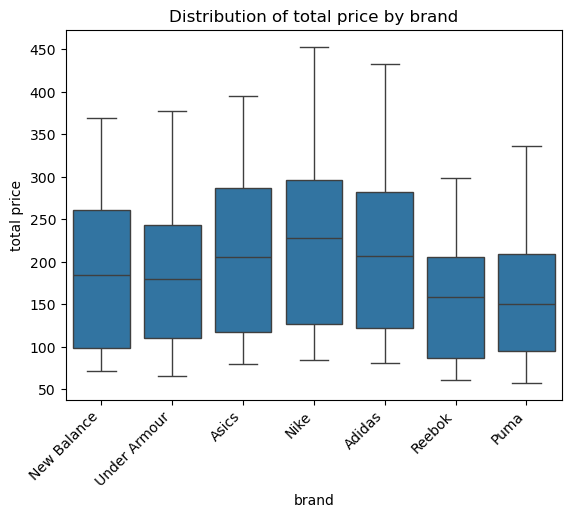

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print('numeric stats final_price \n',df_sneakers['final_price'].describe())
# Top-2 brands by final_price
print(df_sneakers.groupby('brand')['final_price'].sum().sort_values(ascending=False).head(2))
print(df_sneakers.groupby('brand')['final_price'].sum().sort_values(ascending=True).head(2))


df = df_sneakers[['brand','final_price']]
df.rename(columns={'final_price':'total price'}, inplace=True)

sns.boxplot(data=df, x='brand', y='total price').set_title('Distribution of total price by brand')
plt.xticks(rotation=45, ha='right')
plt.show()

Conclusion: the total payment amounts have a moderate range, with no extremely low or high values. The trend follows the price per pair. The two brands with the highest total amounts are Nike and Adidas, and the two with the lowest totals are Reebok and Puma.  There are no anomalies or outliers. The data is suitable for analysis.

### 3) Choose one entity from the list: cities, stores, customers, sneaker brands, and find:   - the number of unique objects of this entity,   - how many times each unique object of this entity appears in the dataset.     Use Python scripts and bar charts to visualize each result.

7
['New Balance' 'Under Armour' 'Asics' 'Nike' 'Adidas' 'Reebok' 'Puma']
brand
Reebok          765
Under Armour    719
Adidas          716
Puma            705
New Balance     699
Asics           699
Nike            697
Name: count, dtype: int64


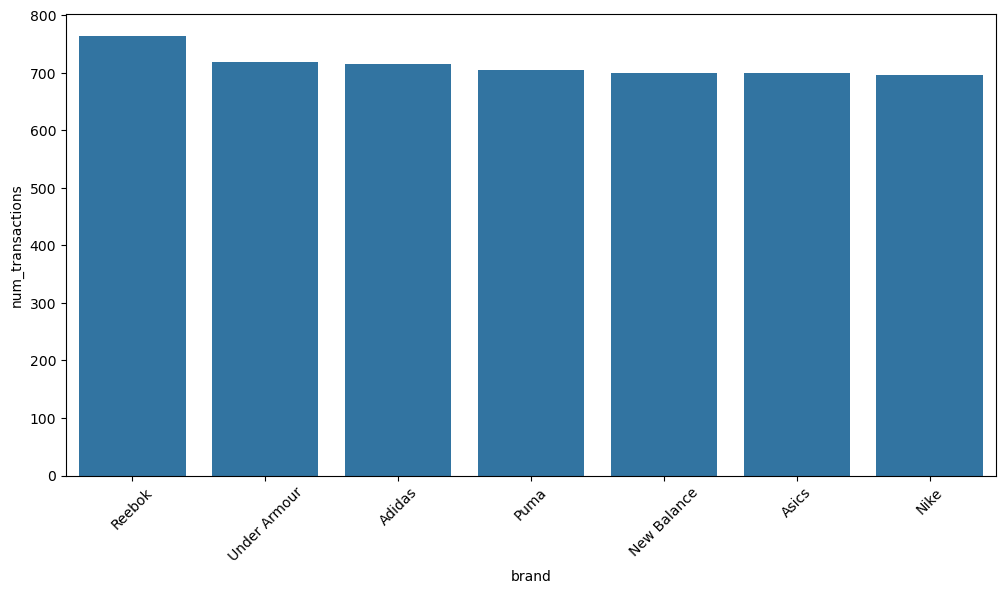

In [86]:
# number of unique objects
print(df['brand'].nunique())
# unique object brand
print(df['brand'].unique())
# how many times each unique object appears in the dataset
print(df_sneakers['brand'].value_counts())

brand_counts = df_sneakers['brand'].value_counts().reset_index()
brand_counts.columns = ['brand', 'num_transactions']

plt.figure(figsize=(12,6))
sns.barplot(x='brand', y='num_transactions', data=brand_counts, orient='v')
plt.xticks(rotation=45)
plt.show()

### 4) Choose one of the entities from point 3 and find:   - the total amount of money connected with each of its objects in the transactions,   - the TOP 3 objects by the amount of money connected with them,   - the monthly dynamics for this entity by total monthly amounts of money (there is an example in the lesson materials on how to convert a transaction date into a month!).     Use Python scripts and also one suitable type of chart (linear, bar, or pie) to visualize each result.

4.1 The total amount of money connected with each brand in the transactions

In [87]:
brand_revenue = (
    df_sneakers.groupby('brand')['final_price']
    .sum()
    .reset_index()
    .sort_values(by='final_price', ascending=False)
)

print(brand_revenue)

          brand  final_price
3          Nike    156879.89
0        Adidas    153791.46
1         Asics    147829.92
6  Under Armour    134668.97
2   New Balance    131424.43
5        Reebok    119202.85
4          Puma    112704.97


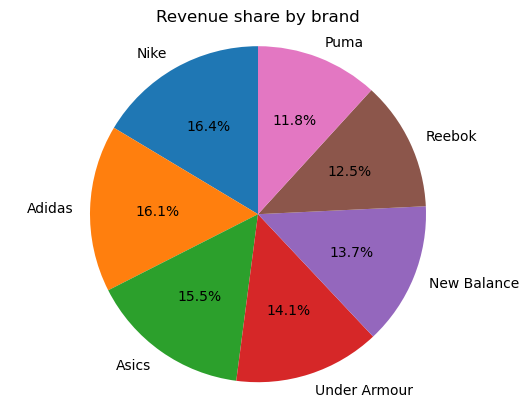

In [88]:
plt.pie(
    brand_revenue['final_price'],
    labels=brand_revenue['brand'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue share by brand')
plt.axis('equal')
plt.show()


4.2 Еhe TOP 3 brand by the amount of money 

    brand  final_price
3    Nike    156879.89
0  Adidas    153791.46
1   Asics    147829.92


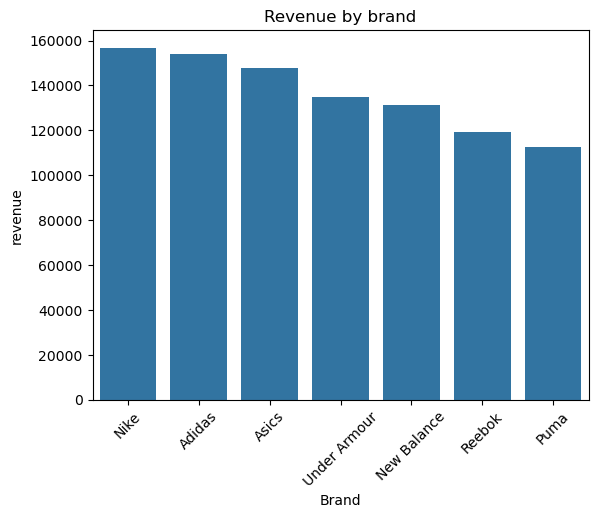

In [89]:
top_3_brands = brand_revenue.head(3)
print(top_3_brands)

sns.barplot(x='brand', y='final_price', data=brand_revenue)
plt.title('Revenue by brand')
plt.xlabel('Brand')
plt.ylabel('revenue')
plt.xticks(rotation=45)
plt.show()

Plotting Total Revenue per Brand for Each Country (Stacked Bar Chart)

brand            Adidas     Asics  New Balance      Nike      Puma    Reebok  \
store_country                                                                  
Poland         74118.65  64739.36     61494.26  83602.69  60705.63  57661.62   
Ukraine        79672.81  83090.56     69930.17  73277.20  51999.34  61541.23   

brand          Under Armour  
store_country                
Poland             71066.80  
Ukraine            63602.17  


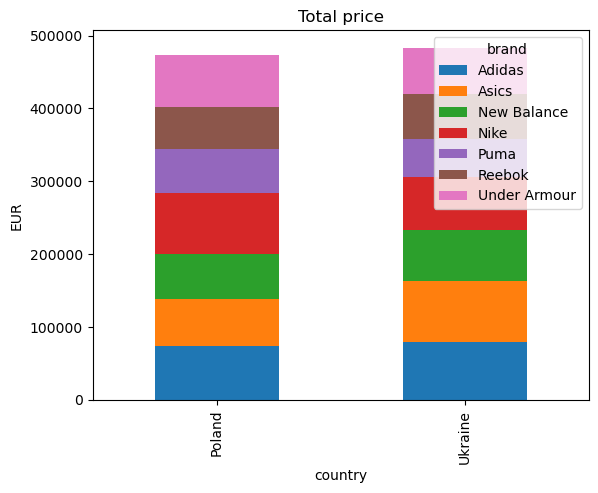

In [90]:
brand_country_revenue = (
    df_sneakers.groupby(['brand', 'store_country'])['final_price']
    .sum()
    .reset_index()
)

pivot_table = brand_country_revenue.pivot(
    index='store_country',
    columns='brand',
    values='final_price'
)

print(pivot_table)


pivot_table.plot(kind='bar', stacked=True,
            title='Total price',
            xlabel='country', ylabel='EUR')
plt.show()

4.3 The monthly dynamics for brands by total monthly amounts of money

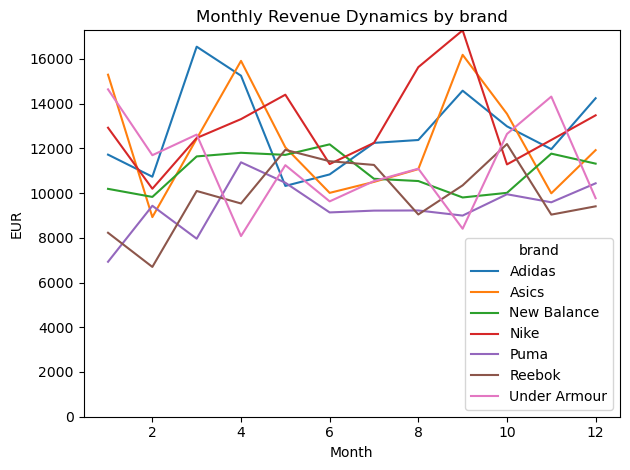

In [91]:
monthly_brand_revenue = (
    df_sneakers.groupby(['month', 'brand'])['final_price']
    .sum()
    .reset_index()
)

df_res = monthly_brand_revenue.pivot(index='month', columns='brand', values='final_price')
ylim_min = 0
ylim_max = round(df_res.max().max())

df_res.plot(
    title='Monthly Revenue Dynamics by brand',
    xlabel='Month',
    ylabel='EUR',
    ylim=(ylim_min, ylim_max)
)

plt.tight_layout()
plt.show()


5. Mini-report

1) **General dataset info**
- number of rows: 5000  
- number of columns: 19  
- missing values: none  
- duplicate transaction IDs: none  

2) **Basic statistics**
- `num_pairs`: no abnormal values  
- `price_per_pair`: normal range  
- `final_price`: no anomalies  

3) **Time axis check**
- date format: valid  
- range: **2024-01-01 → 2024-12-30**  
- no gaps in daily records  

**Conclusion:**  
- data is ready for further analysis,  
- dataset has a temporal structure (useful for time-series analysis).

The data analysis by country showed that the contribution of different brands to total revenue is approximately equal. In Poland and Ukraine, the revenue distribution by brand is similar. Monthly revenue for different brands varies, but the trends are generally similar (The reasons for changes in Under Armour sales should be examined in detail.).Sneakers from the brand Reebok, which has the lowest price per pair among all brands, are purchased most frequently. Sneakers from Nike and Adidas are bought the least often, but they contribute the most to total revenue because of their high price per pair.

## Task 2

1. Choose one geolocation and one year.

In [69]:
# Choose city in Poland Bialystok, year = 2022
import pandas as pd
from sqlalchemy import create_engine

# Connection string
engine = create_engine("mssql+pyodbc://@localhost/meteo_sandbox_db?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")
query ="""with temperature2022
AS (
    SELECT
        gob.geoobjectId, m.timePointId, tp.year, tp.month, tp.day, tp.hour, tp.minute,
        ROUND(m.temperature, 2) AS temperature,
        gob.national_name AS [name]
    FROM dbo.Measurement AS m
        INNER JOIN dbo.TimePoint         AS tp   ON m.timePointId = tp.timePointId
        INNER JOIN dbo.GeoObjectGeoPoint AS gogp ON gogp.geoPointId = m.geoPointId
        INNER JOIN dbo.GeoObject         AS gob  ON gob.geoObjectId = gogp.geoObjectId
    WHERE tp.year = 2022
and gob.ascii_name LIKE 'Bialystok'
and gob.countryId = 180
and gob.geonameClassId = 4)
select * from temperature2022;
"""
df_temperature2022 = pd.read_sql(query, engine)

# View loaded data
print(df_temperature2022.head(10))

   geoobjectId  timePointId  year  month  day  hour  minute  temperature  \
0     12068030       596745  2022      1   12     2       0        -11.0   
1     12068030       602373  2022      3   11    17       0         -0.7   
2     12068030       609121  2022      5   21     0       0         13.2   
3     12068030       596744  2022      1   12     1      45        -11.1   
4     12068030       596746  2022      1   12     2      15        -11.1   
5     12068030       602375  2022      3   11    17      30         -0.9   
6     12068030       602374  2022      3   11    17      15         -0.8   
7     12068030       602371  2022      3   11    16      30         -0.6   
8     12068030       602372  2022      3   11    16      45         -0.6   
9     12068030       627465  2022     11   28     2       0         -0.2   

        name  
0  Białystok  
1  Białystok  
2  Białystok  
3  Białystok  
4  Białystok  
5  Białystok  
6  Białystok  
7  Białystok  
8  Białystok  
9  Białystok 

Let’s make sure that the source data is correct, and does not contain anomalies or outliers.

In [70]:
import pandas as pd

# general structure,  number of columns, the number of rows, and the data types of the columns
print(df_temperature2022.info())

# numeric columns summary
print(df_temperature2022.describe())

# string columns summary
print(df_temperature2022.describe(include=object))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   geoobjectId  35040 non-null  int64  
 1   timePointId  35040 non-null  int64  
 2   year         35040 non-null  int64  
 3   month        35040 non-null  int64  
 4   day          35040 non-null  int64  
 5   hour         35040 non-null  int64  
 6   minute       35040 non-null  int64  
 7   temperature  35040 non-null  float64
 8   name         35040 non-null  object 
dtypes: float64(1), int64(7), object(1)
memory usage: 2.4+ MB
None
       geoobjectId    timePointId     year         month           day  \
count      35040.0   35040.000000  35040.0  35040.000000  35040.000000   
mean    12068030.0  613200.500000   2022.0      6.526027     15.720548   
std            0.0   10115.321053      0.0      3.447901      8.796373   
min     12068030.0  595681.000000   2022.0      1.000000      1.000

In [71]:
# duplicated value
print(df_temperature2022.isna().sum())
# duplicated df_temperature2022
print('duplicated timePointId', df_temperature2022['timePointId'].count() - df_temperature2022['timePointId'].nunique())

geoobjectId    0
timePointId    0
year           0
month          0
day            0
hour           0
minute         0
temperature    0
name           0
dtype: int64
duplicated timePointId 0


In [72]:
# To control date continuity, we add an additional column date
df_temperature2022["date"] = pd.to_datetime(df_temperature2022[["year", "month", "day"]]).dt.date

s = pd.Series(df_temperature2022["date"].unique())
s_date = pd.to_datetime(s).sort_values(ascending=True)

# min–max dates
print(s_date.min())
print(s_date.max())

# gaps in dates
print('gaps in dates',s_date.diff().value_counts())


2022-01-01 00:00:00
2022-12-31 00:00:00
gaps in dates 1 days    364
Name: count, dtype: int64


Mini-report

1) **General dataset info**
- number of rows: 35040  
- number of columns: 8 
- missing values: none  
- duplicate timePointId: none  

2) **Basic statistics**
- `temperature`: no anomalies  
- `month`: normal range  
- `day`: normal range 
- `hour`: normal range 

3) **Time axis check**
- date format: valid  
- range: **2022-01-01 → 2022-12-31**  
- no gaps in daily records  

**Conclusion:**  
- data is ready for further analysis,  
- dataset has a temporal structure (useful for time-series analysis).

2.  With an SQL query, calculate for this geolocation two average temperatures for each month of the year – the first average temperature should be calculated from the maximum daily temperature, and the second from the minimum daily temperature.

In [73]:
import pandas as pd
from sqlalchemy import create_engine

# Connection string
engine = create_engine("mssql+pyodbc://@localhost/meteo_sandbox_db?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")
query ="""with TemperatureMeasurement2022
AS (
    SELECT
        tp.year, tp.month, tp.day,max(m.temperature) AS max_temperature, min(m.temperature) AS min_temperature
    FROM dbo.Measurement AS m
        INNER JOIN dbo.TimePoint         AS tp   ON m.timePointId = tp.timePointId
        INNER JOIN dbo.GeoObjectGeoPoint AS gogp ON gogp.geoPointId = m.geoPointId
        INNER JOIN dbo.GeoObject         AS gob  ON gob.geoObjectId = gogp.geoObjectId
        INNER JOIN dbo.Country           AS c    ON c.countryId = gob.countryId
    WHERE tp.year = 2022
and gob.ascii_name LIKE 'Bialystok'
and gob.countryId = 180
and gob.geonameClassId = 4
 GROUP BY tp.year, tp.month, tp.day ),
    avg_TemperatureMeasurement2022 AS (
    SELECT year, month, round(avg(max_temperature), 2) AS avg_max_temperature, round(avg(min_temperature), 2) as avg_min_temperature
    FROM TemperatureMeasurement2022
    GROUP BY year, month
    )
select year, month, avg_max_temperature, avg_min_temperature  from avg_TemperatureMeasurement2022;
"""
df_avg_temperature2022 = pd.read_sql(query, engine)

print(df_avg_temperature2022)

# numeric columns summary
print(df_avg_temperature2022.describe())

    year  month  avg_max_temperature  avg_min_temperature
0   2022     11                 4.77                 0.19
1   2022      1                 0.70                -4.25
2   2022      5                17.15                 5.89
3   2022      9                16.52                 7.28
4   2022      7                23.22                13.20
5   2022     10                14.65                 6.11
6   2022     12                -1.77                -5.89
7   2022      8                27.00                15.06
8   2022      3                 7.00                -3.40
9   2022      4                 9.97                 1.05
10  2022      2                 3.91                -2.00
11  2022      6                23.70                13.07
         year      month  avg_max_temperature  avg_min_temperature
count    12.0  12.000000            12.000000            12.000000
mean   2022.0   6.500000            12.235000             3.859167
std       0.0   3.605551             9.559554

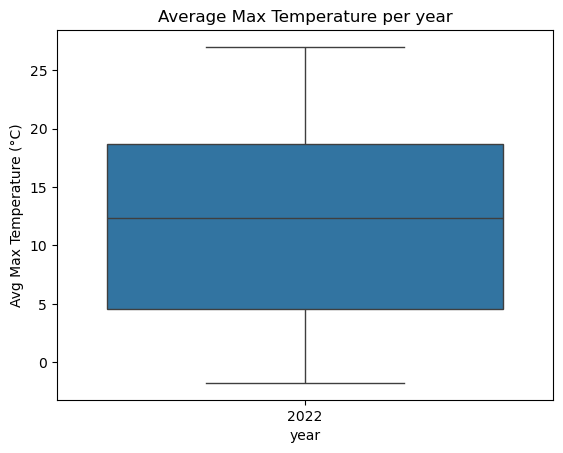

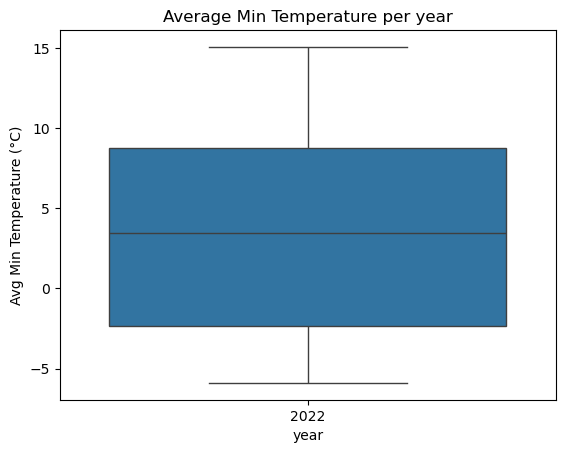

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_avg_temperature2022, x='year', y='avg_max_temperature')
plt.title('Average Max Temperature per year')
plt.ylabel('Avg Max Temperature (°C)')
plt.show()

sns.boxplot(data=df_avg_temperature2022, x='year', y='avg_min_temperature')
plt.title('Average Min Temperature per year')
plt.ylabel('Avg Min Temperature (°C)')
plt.show()

3.3. Create charts with these temperatures (linear or bar type), using the Python material we studied.

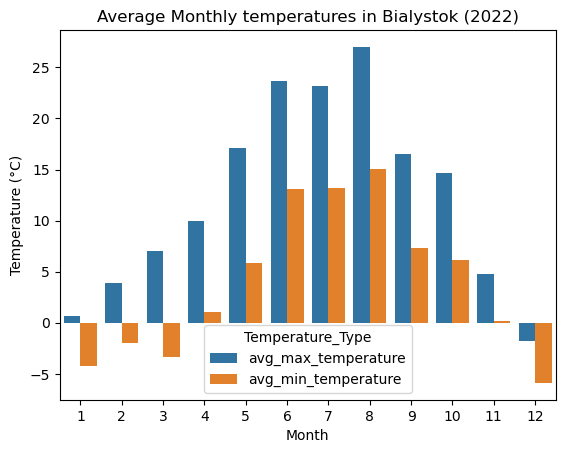

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_m = df_avg_temperature2022.melt(
    id_vars=['month'], 
    value_vars=['avg_max_temperature', 'avg_min_temperature'],
    var_name='Temperature_Type', 
    value_name='Temperature'
)

sns.barplot(x='month', y='Temperature', hue='Temperature_Type', data=df_m)
plt.title('Average Monthly temperatures in Bialystok (2022)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()

Conclusion: This data shows the average monthly temperatures in Bialystok for 2022. Max temperatures are higher in summer and lower in winter, and min temperatures follow the same pattern. The temperatures look normal, with no missing values or strange numbers. The dataset is ready for doing more analysis.